# Explore a Document Collection

Every retrieval system starts with a **collection** — the set of documents we want
to search. This notebook lets you load any collection, inspect its structure,
and observe basic text statistics before applying retrieval models.

**Learning goals:**
- Understand the standard document structure: `id`, `source`, `text`, + metadata
- See how different collections split source material into retrieval units
- Observe Zipf's law and term statistics on real (and synthetic) text

In [1]:
from shared.collections import load_collection, available_collections
from shared.display import print_table, display_md
from shared.text import tokenize, remove_stopwords, pipeline
from collections import Counter
import matplotlib.pyplot as plt
import ipywidgets as widgets

## Available Collections

In [2]:
# List all registered collections from the registry
print_table(
    [[c["name"], c["description"]] for c in available_collections()],
    headers=["Name", "Description"]
)

| Name                               | Description                                                           |
|:-----------------------------------|:----------------------------------------------------------------------|
| books                              | Gutenberg books split by chapter (~10 books, multilingual)            |
| books-alice                        | Alice's Adventures in Wonderland (Lewis Carroll)                      |
| books-de                           | German books                                                          |
| books-en                           | English books                                                         |
| books-es                           | Spanish books                                                         |
| books-fr                           | French books                                                          |
| books-frankenstein                 | Frankenstein (Mary Shelley)                                           |
| books-moby-dick                    | Moby Dick (Herman Melville)                                           |
| books-pl                           | Polish books                                                          |
| books-pride                        | Pride and Prejudice (Jane Austen)                                     |
| books-scarlet                      | A Study in Scarlet (Arthur Conan Doyle)                               |
| books-zh                           | Chinese texts                                                         |
| mini                               | 12 hand-crafted documents for formula tracing (Ch. 1 running example) |
| movies                             | Kaggle movie dataset (~45,000 movies with metadata)                   |
| movies-small                       | 500 movies (fast loading for demos)                                   |
| slides                             | All lecture slides combined (~500+ pages)                             |
| slides-acoustic-features           | Lecture: Acoustic Features                                            |
| slides-advanced-text-processing    | Lecture: Advanced Text Processing                                     |
| slides-classical-text-retrieval    | Lecture: Classical Text Retrieval                                     |
| slides-index-text-retrieval        | Lecture: Index for Text Retrieval                                     |
| slides-introduction                | Lecture: Introduction                                                 |
| slides-ml-methods                  | Lecture: ML Methods                                                   |
| slides-multimodal-content-analysis | Lecture: Multimodal Content Analysis                                  |
| slides-performance-evaluation      | Lecture: Performance Evaluation                                       |
| slides-rag                         | Lecture: Retrieval Augmented Generation                               |
| slides-semantic-search             | Lecture: Semantic Search                                              |
| slides-spatiotemporal-features     | Lecture: Spatiotemporal Features                                      |
| slides-structural-features         | Lecture: Structural Features                                          |
| slides-vector-search               | Lecture: Vector Search                                                |
| slides-visual-features             | Lecture: Visual Features                                              |
| slides-web-search                  | Lecture: Web Search                                                   |

## Select a Collection

Pick a collection for the rest of this notebook. Each collection handles its
own data — downloading, caching, and splitting into retrieval units automatically.

In [3]:
# Build dropdown from the registry — every collection is a first-class entry
_names = [c["name"] for c in available_collections()]

_dropdown = widgets.Dropdown(
    options=_names,
    value="slides-classical-text-retrieval",
    description="Collection:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px"),
)
display(_dropdown)

Dropdown(description='Collection:', index=18, layout=Layout(width='450px'), options=('books', 'books-alice', '…

In [4]:
# Load the selected collection
collection = load_collection(_dropdown.value)

display_md(
    f"**{collection.name}** — {collection.description}\n\n"
    f"- Documents: **{len(collection)}** retrieval units\n"
    f"- Metadata keys: {collection.metadata_keys()}"
)

  Downloading: https://dmi.unibas.ch/fileadmin/user_upload/dmi/Studium/Computer_Science/Vorlesungen_HS23/Multimedia_Retrieval/HS25/02_ClassicalTextRetrieval.pdf


**slides-classical-text-retrieval** — Lecture: Classical Text Retrieval

- Documents: **45** retrieval units
- Metadata keys: ['chapter', 'page']

## Inspect the Documents

Each retrieval unit is a flat dictionary with at least `id`, `source`, and `text`.

In [5]:
# Show the first 10 documents
rows = []
for doc in list(collection)[:10]:
    rows.append([
        doc["id"],
        doc["source"],
        doc["text"][:80] + ("..." if len(doc["text"]) > 80 else ""),
    ])

print_table(rows, headers=["ID", "Source", "Text (preview)"])

| ID                           | Source                   | Text (preview)                                                                      |
|:-----------------------------|:-------------------------|:------------------------------------------------------------------------------------|
| classical-text-retrieval-p01 | classical-text-retrieval | Computer Science / 15731 - 01 / 2025 Multimedia Retrieval Chapter 2: Classical T... |
| classical-text-retrieval-p02 | classical-text-retrieval | 2.1 Introduction Text retrieval began in the 1950s and 1960s with pioneering wor... |
| classical-text-retrieval-p03 | classical-text-retrieval | As collections grew, the Boolean model needed an extension to better organize an... |
| classical-text-retrieval-p04 | classical-text-retrieval | In the 1970s, the classical Vector - Space and Probabilistic retrieval models ap... |
| classical-text-retrieval-p05 | classical-text-retrieval | 2.2 Fundamental Flows For this chapter and the ones that follow, we introduce a ... |
| classical-text-retrieval-p06 | classical-text-retrieval | b) Split a) Ingest Offline Phase: The diagram on the left illustrates the indexi... |
| classical-text-retrieval-p07 | classical-text-retrieval | Online Phase: The figure on the right shows how a user query is processed and ma... |
| classical-text-retrieval-p08 | classical-text-retrieval | 2.3 Feature Extraction Pipeline Before the system can index documents or match u... |
| classical-text-retrieval-p09 | classical-text-retrieval | 2.3.1 Extract Content and Metadata Attributes Text documents are available in di... |
| classical-text-retrieval-p10 | classical-text-retrieval | Let’s use the example of HTML to illustrate some aspects for metadata generation... |

In [6]:
# Look at a random document in full (re-run this cell to see another)
import random

doc = random.choice(collection.documents())
meta_lines = "\n".join(f"- **{key}:** {doc.get(key, '—')}" for key in collection.metadata_keys())

display_md(
    f"### Document `{doc['id']}`\n\n"
    f"- **Source:** {doc['source']}\n"
    f"{meta_lines}\n\n"
    f"---\n\n"
    f"{doc['text']}"
)

### Document `classical-text-retrieval-p37`

- **Source:** classical-text-retrieval
- **chapter:** 1
- **page:** 37

---

To calculate the 𝑐 𝑗 - values, the BIR model starts with initial estimates for a first result list, and then refines these estimates based on user feedback to enhance the results. With ongoing user input on relevant and non - relevant documents in the outcomes, we can iteratively adjust the estimates and offer better outcomes. – We introduced 𝑟 𝑗 and 𝑛 𝑗 as the probabilities that a relevant and non - relevant document contains the term 𝑡 𝑗 , respectively. With the user's relevance assessment, we now possess subsets of relevant and non - relevant documents, which allow us to estimate these probabilities by counting the occurrences of term 𝑡 𝑗 in these subsets – Initial Estimates: In the absence of feedback, we assume that query terms are more likely to appear in relevant documents, and in non - relevant documents they follow their document frequency. The following estimates are used initially to compute the 𝑐 𝑗 - values ( 𝑛 𝑗 includes smoothing) – Estimates with Feedback: in each iteration, we ask the user to rate the 𝐾 retrieved documents and annotate them with relevant (R) and non - relevant (NR). Let 𝐿 be the number of documents that the user marked as relevant. Further let 𝑘 𝑗 be the number of retrieved documents that contain the term 𝑡 𝑗 (that is the document frequency of 𝑡 𝑗 over the set of retrieved documents), and let 𝑙 𝑗 be the number of retrieved and relevant documents that contain the term 𝑡 𝑗 (that is the document frequency of 𝑡 𝑗 over the set of retrieved and relevant documents). With that, we can estimate new values for 𝑟 𝑗 and 𝑛 𝑗 by counting: We employ the values 0.5 and 1 in the formula above to avoid numerical problems (0 - divisions). When no feedback is given, with 𝐿 = 𝑙 𝑗 = 0 , we can set 𝐾 = 𝑁 and 𝑘 𝑗 = 𝑑𝑓 ( 𝑡 𝑗 ) to justify the initial estimates. – The more user feedback we gather, the more accurate the estimates for 𝑟 𝑗 and 𝑛 𝑗 become. However, users might be reluctant to provide feedback. 𝑟 𝑗 = 0 . 5 , 𝑛 𝑗 = 𝑑𝑓 𝑡 𝑗 + 0 . 5 𝑁 + 1 ∀ 𝑗 : 𝑞 𝑗 = 1 𝑟 𝑗 = 𝑙 𝑗 + 0 . 5 𝐿 + 1 , 𝑛 𝑗 = 𝑘 𝑗 − 𝑙 𝑗 + 0 . 5 𝐾 − 𝐿 + 1 ∀ 𝑗 : 𝑞 𝑗 = 1

---
## Collection Statistics

How long are the documents? This determines how meaningful term frequencies are
and how well IDF can discriminate.

In [7]:
# Document lengths (in tokens, after basic tokenization)
lengths = []
for doc in collection:
    tokens = tokenize(doc["text"])
    lengths.append(len(tokens))

display_md(
    f"**Token counts per document:**\n\n"
    f"| Statistic | Value |\n"
    f"|-----------|-------|\n"
    f"| Documents | {len(lengths)} |\n"
    f"| Total tokens | {sum(lengths):,} |\n"
    f"| Mean length | {sum(lengths)/len(lengths):.1f} tokens |\n"
    f"| Shortest | {min(lengths)} tokens |\n"
    f"| Longest | {max(lengths)} tokens |"
)

**Token counts per document:**

| Statistic | Value |
|-----------|-------|
| Documents | 45 |
| Total tokens | 15,721 |
| Mean length | 349.4 tokens |
| Shortest | 63 tokens |
| Longest | 850 tokens |

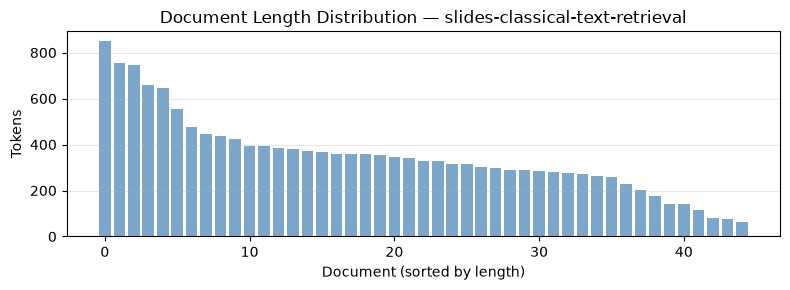

In [8]:
# Distribution of document lengths
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(lengths)), sorted(lengths, reverse=True), color="steelblue", alpha=0.7)
ax.set_xlabel("Document (sorted by length)")
ax.set_ylabel("Tokens")
ax.set_title(f"Document Length Distribution — {collection.name}")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## Vocabulary and Term Frequencies

We tokenize the entire collection and look at the vocabulary.

In [9]:
# Tokenize all documents (lowercase, split, remove stopwords)
all_tokens = []
doc_tokens = {}
for doc in collection:
    tokens = remove_stopwords(tokenize(doc["text"]), collection.language or "all")
    doc_tokens[doc["id"]] = tokens
    all_tokens.extend(tokens)

# Collection frequency (total occurrences)
cf = Counter(all_tokens)

# Document frequency (how many docs contain each term)
df = Counter()
for tokens in doc_tokens.values():
    df.update(set(tokens))

vocab = sorted(df.keys())

display_md(
    f"**Vocabulary:** {len(vocab):,} unique terms | "
    f"**Total tokens:** {len(all_tokens):,} (after stop word removal)"
)

**Vocabulary:** 2,188 unique terms | **Total tokens:** 10,352 (after stop word removal)

In [10]:
# Most frequent terms
print_table(
    [[term, count, df[term], f"{df[term]/len(collection)*100:.0f}%"]
     for term, count in cf.most_common(20)],
    headers=["Term", "Collection Freq.", "Doc. Freq.", "% docs"]
)

| Term      |   Collection Freq. |   Doc. Freq. | % docs   |
|:----------|-------------------:|-------------:|:---------|
| 𝑗         |                299 |           15 | 33%      |
| 1         |                259 |           32 | 71%      |
| 𝑖         |                161 |           13 | 29%      |
| term      |                147 |           33 | 73%      |
| 0         |                143 |           21 | 47%      |
| documents |                138 |           35 | 78%      |
| 𝑡         |                134 |           19 | 42%      |
| query     |                131 |           31 | 69%      |
| document  |                129 |           33 | 73%      |
| 𝐷         |                127 |           17 | 38%      |
| terms     |                124 |           38 | 84%      |
| 2         |                108 |           28 | 62%      |
| retrieval |                 87 |           30 | 67%      |
| 𝑘         |                 82 |           10 | 22%      |
| 𝑄         |                 74 |           12 | 27%      |
| relevant  |                 71 |           23 | 51%      |
| 𝑙         |                 65 |            6 | 13%      |
| 𝑑         |                 56 |            9 | 20%      |
| model     |                 54 |           20 | 44%      |
| 5         |                 50 |           14 | 31%      |

In [11]:
# Rarest terms (appear in only 1 document)
rare = [t for t, f in df.items() if f == 1]
display_md(
    f"**Rare terms** (df=1): {len(rare)} / {len(vocab)} "
    f"({len(rare)/len(vocab)*100:.0f}% of vocabulary)\n\n"
    f"Examples: {', '.join(sorted(rare)[:20])}"
)

**Rare terms** (df=1): 1235 / 2188 (56% of vocabulary)

Examples: 01, 03, 031, 062, 08, 09, 1000, 1002, 1108, 1145, 12, 13, 138, 1500000019, 1561, 176, 1950s, 1960s, 1976, 1980s

---
## Zipf's Law

The frequency distribution of terms in natural language follows a power law.
On a log-log plot, this appears as a straight line.

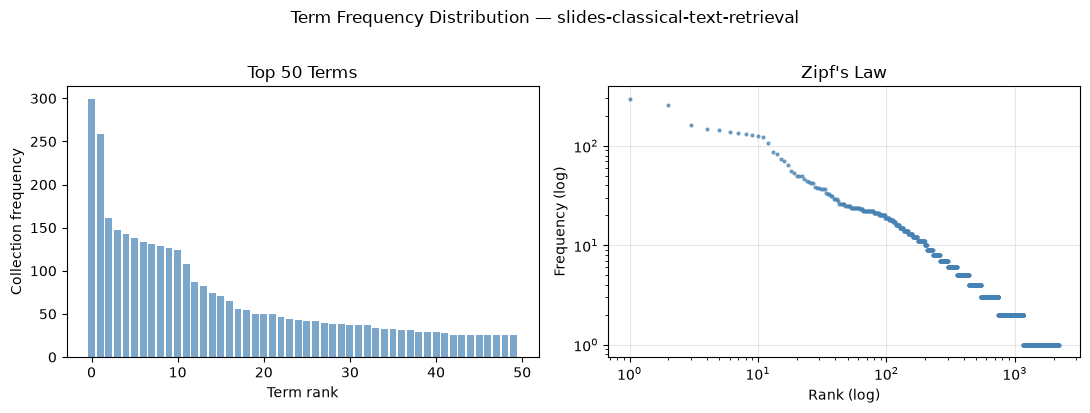

In [12]:
# Sort by frequency
cf_sorted = cf.most_common()
ranks = range(1, len(cf_sorted) + 1)
freqs = [f for _, f in cf_sorted]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Linear scale
ax1.bar(range(len(freqs[:50])), freqs[:50], color="steelblue", alpha=0.7)
ax1.set_xlabel("Term rank")
ax1.set_ylabel("Collection frequency")
ax1.set_title("Top 50 Terms")

# Log-log (Zipf)
ax2.loglog(ranks, freqs, "o", markersize=2, color="steelblue", alpha=0.7)
ax2.set_xlabel("Rank (log)")
ax2.set_ylabel("Frequency (log)")
ax2.set_title("Zipf's Law")
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Term Frequency Distribution — {collection.name}", y=1.02)
plt.tight_layout()
plt.show()

---
## Try It Yourself

Go back to the dropdown above and select a different collection — then
re-run the cells below it to see how statistics change.

Things to explore:
- How does MINI compare to a real lecture? (Select "mini" above)
- What happens when you load ALL slides? (Select "slides (all)")
- Which lecture has the richest vocabulary?

In [13]:
# You can also load collections programmatically:
#
#   load_collection("slides", pdf="semantic-search")
#   load_collection("slides", pdf="all")
#   load_collection("slides", pdf="https://example.com/custom.pdf")
#   load_collection("mini")